# Thesis Project: Predictive Stock Pricing Model for Aluminum & Steel Companies

This notebook explores the historical stock performance of selected steel and aluminum companies, 
with a particular focus on how the 2018 US steel and aluminum tariffs impacted these companies. 
We will use this analysis to inform a predictive model for how potential 2025 tariffs might affect stock prices.

---


In [53]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ks_2samp, levene
import statsmodels.api as sm
from tqdm import tqdm


#### SECTION 1:DATA DOWNLOAD

In [54]:

# Your stock tickers
tickers = ["SIM", 'HPS-A.TO', 'TSLA', 'CPB', 'GM', 'AA', 'F', 'CAT']

#["SIM", 'HPS-A.TO', 'TSLA', 'CPB', 'GM', 'AA', 'F', 'CAT']
market_ticker = "^GSPC"
risk_free_ticker = "^IRX"

# Download data
price_data = yf.download(tickers, start="2017-02-20", end="2018-07-01")["Close"]
market_data = yf.download(market_ticker, start="2017-02-20", end="2018-07-01")["Close"]
risk_free = yf.download(risk_free_ticker, start="2017-02-20", end="2018-07-01")["Close"] / 100

# Forward-fill missing risk-free data and align to business days
price_data = price_data.resample('B').ffill()
market_data = market_data.resample('B').ffill()
risk_free = risk_free.resample('B').ffill()


# Compute daily log returns
log_returns = np.log(price_data / price_data.shift(1))
market_returns = np.log(market_data / market_data.shift(1))

log_returns.tail()

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker,AA,CAT,CPB,F,GM,HPS-A.TO,SIM,TSLA
Date,,,,,,,,
2018-06-25,-0.028949,-0.024303,0.089879,-0.012959,-0.015637,0.004420,-0.003450,-0.001860
2018-06-26,0.034203,-0.007644,-0.022026,0.001738,0.009802,-0.002208,0.021653,0.026638
2018-06-27,-0.001311,-0.006885,-0.034979,-0.008718,-0.015729,-0.069783,-0.009060,0.007283
2018-06-28,0.015834,0.010494,0.021330,-0.012335,0.003709,0.000000,0.048844,0.015639
2018-06-29,0.008784,-0.002650,-0.005167,-0.018793,-0.028030,-0.016727,0.027780,-0.020148


#### SECTION 2: SUMMARY STATISTICS

In [55]:
# Summary Statistics
summary_stats = pd.DataFrame({
    "Mean Return": log_returns.mean(),
    "Std Dev (Volatility)": log_returns.std(),
    "Min Return": log_returns.min(),
    "Max Return": log_returns.max(),
    "Skewness": log_returns.skew(),
    "Kurtosis": log_returns.kurt()
})

# Print Summary Statistics
print("Summary Statistics of Log Returns:")
print(summary_stats)

Summary Statistics of Log Returns:
          Mean Return  Std Dev (Volatility)  Min Return  Max Return  Skewness   
Ticker                                                                          
AA           0.000854              0.024237   -0.145192    0.093758 -0.650285  \
CAT          0.001099              0.015383   -0.064023    0.075671 -0.259720   
CPB         -0.000905              0.017413   -0.132002    0.089879 -1.640545   
F           -0.000110              0.012401   -0.072817    0.049534 -0.854711   
GM           0.000351              0.015385   -0.040451    0.121096  1.259237   
HPS-A.TO     0.000964              0.015611   -0.069783    0.066249  0.097796   
SIM         -0.000991              0.019445   -0.072196    0.103752  0.420671   
TSLA         0.000638              0.025139   -0.090242    0.092987 -0.098001   

           Kurtosis  
Ticker               
AA         4.794623  
CAT        3.790497  
CPB       14.133475  
F          5.016071  
GM        11.186755  


#### SECTION 3: BASIC VISUALIZATIONS

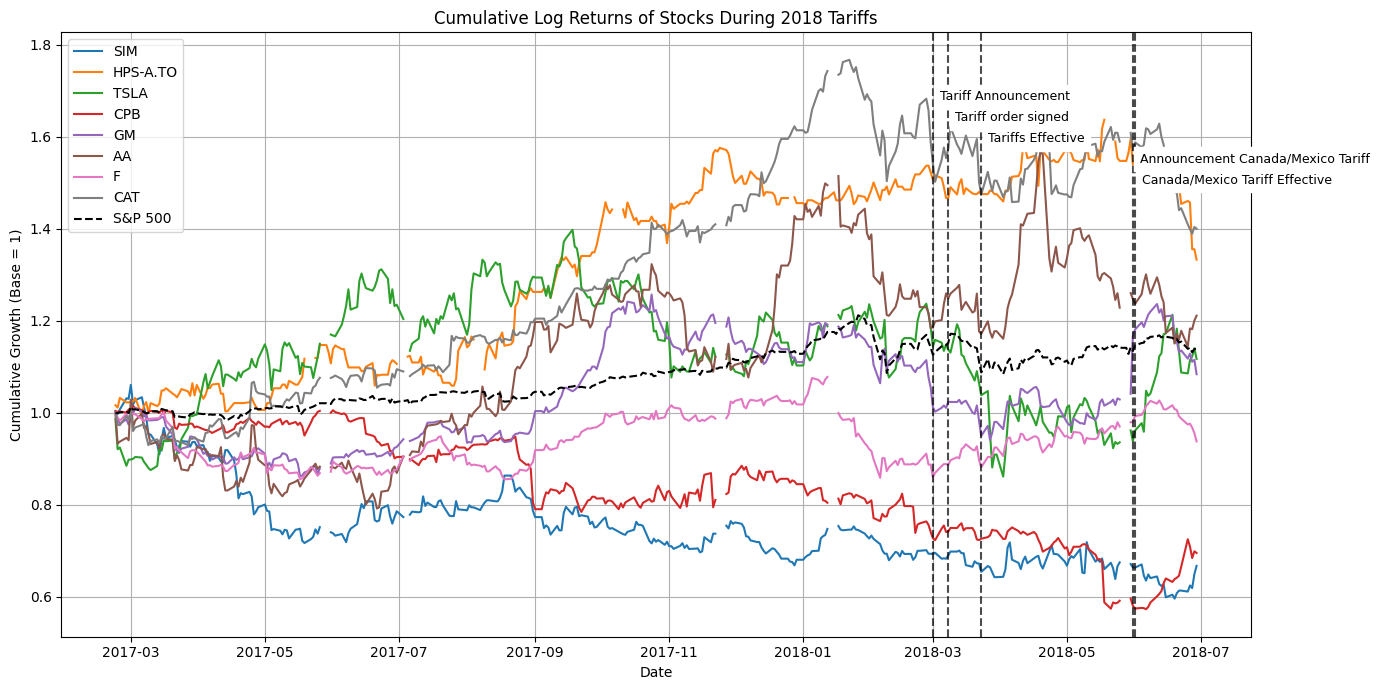

In [56]:
# Compute cumulative returns
cumulative_returns = (log_returns + 1).cumprod()

# Key dates for tariff-related events
event_info = {
    "2018-03-01":"Tariff Announcement",
    "2018-03-08": "Tariff order signed",
    "2018-03-23": "Tariffs Effective",
    "2018-05-31": "Announcement Canada/Mexico Tariff",
    "2018-06-01": "Canada/Mexico Tariff Effective"
}

# Plot cumulative returns
plt.figure(figsize=(14, 7))

# Plot individual stock returns
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

# Plot market index (e.g., S&P 500)
cumulative_market = (market_returns + 1).cumprod()
plt.plot(cumulative_market.index, cumulative_market, label='S&P 500', linestyle='--', color='black')

# Add vertical lines and annotated labels for event dates
y_max = cumulative_returns.max().max()
for i, (event_date_str, event_label) in enumerate(event_info.items()):
    event_date = pd.to_datetime(event_date_str)
    plt.axvline(event_date, color='black', linestyle='--', alpha=0.7)
    # Use plt.annotate for cleaner label placement
    plt.annotate(event_label, 
                 xy=(event_date, y_max * 0.95),
                 xytext=(5, -15*i),  # staggers labels downward
                 textcoords='offset points',
                 rotation=0,
                 fontsize=9,
                 backgroundcolor='white')

# Customize plot
plt.title("Cumulative Log Returns of Stocks During 2018 Tariffs")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth (Base = 1)")
plt.legend()
plt.grid()

# Show plot
plt.tight_layout()
plt.show()



### Section 4: Proving statistical Significance of Event

In [57]:
# 1. Align all series on common dates
common_index = log_returns.index.intersection(market_returns.index).intersection(risk_free.index)
log_returns = log_returns.loc[common_index]
market_returns = market_returns.loc[common_index]
risk_free = risk_free.loc[common_index]

# 2. Define beta estimation window (before first event)
estimation_end_date = "2018-02-28"
log_returns_estimation = log_returns.loc[:estimation_end_date]
market_returns_estimation = market_returns.loc[:estimation_end_date]
risk_free_estimation = risk_free.loc[:estimation_end_date]

# 3. Estimate Beta for Each Stock
betas = {}

for stock in log_returns_estimation.columns:
    excess_stock_return = log_returns_estimation[stock] - risk_free_estimation.squeeze()
    excess_market_return = market_returns_estimation.squeeze() - risk_free_estimation.squeeze()
    
    # Combine into one DataFrame and drop NaNs
    combined = pd.concat([excess_stock_return, excess_market_return], axis=1).dropna()
    if len(combined) < 10:
        print(f"Not enough data to estimate beta for {stock}. Skipping.")
        continue

    y = combined.iloc[:, 0]  # Excess stock return
    X = sm.add_constant(combined.iloc[:, 1])  # Excess market return with intercept

    model = sm.OLS(y, X).fit()
    betas[stock] = model.params[1]  # beta is the coefficient on market excess return

# 4. Save Betas into a DataFrame
betas_df = pd.DataFrame.from_dict(betas, orient='index', columns=['Beta'])

# 5. Print Betas
print("\nEstimated Betas:")
print(betas_df)



Estimated Betas:
              Beta
AA        1.324698
CAT       1.276293
CPB       0.583307
F         0.987277
GM        1.121125
HPS-A.TO  0.324094
SIM       0.371896
TSLA      1.199716


In [58]:
# Event dates
event_dates = [
    "2018-03-01",  # Tariff Announcement
    "2018-03-08",  # Tariff Order Signed
    "2018-03-23",  # Tariffs Effective
    "2018-05-31",  # Announcement Canada/Mexico Tariff
    "2018-06-01"   # Canada/Mexico Tariff Effective
]

# Convert to datetime
event_dates = pd.to_datetime(event_dates)

# Initialize results dictionary
CAR_results = {}

for event_date in event_dates:
    print(f"\nAnalyzing Event on {event_date.date()}...")

    # Define event window: from   4 days before to 4 days after
    window_start = event_date - pd.Timedelta(days=4)
    window_end = event_date + pd.Timedelta(days=4)
    window_mask = (log_returns.index >= window_start) & (log_returns.index <= window_end)

    # Slice the data for the window
    log_returns_window = log_returns.loc[window_mask]
    market_returns_window = market_returns.loc[window_mask]
    risk_free_window = risk_free.loc[window_mask]

    # Calculate Expected Returns
    expected_returns = pd.DataFrame(index=log_returns_window.index, columns=log_returns_window.columns)

    for stock in log_returns_window.columns:
        beta = betas.get(stock)
        if beta is None:
            continue  # Skip stocks with missing beta
        expected_returns[stock] = risk_free_window.squeeze() + beta * (market_returns_window.squeeze() - risk_free_window.squeeze())

    # Calculate Abnormal Returns
    abnormal_returns = log_returns_window - expected_returns

    # Calculate CARs (Cumulative Abnormal Returns)
    CAR = abnormal_returns.sum()

    # Store results
    CAR_results[event_date.date()] = CAR

# Convert CAR results into a DataFrame
CAR_df = pd.DataFrame(CAR_results).T  # Transpose for easier reading
print("\nCumulative Abnormal Returns (CAR) per Event:")
print(CAR_df)



Analyzing Event on 2018-03-01...

Analyzing Event on 2018-03-08...

Analyzing Event on 2018-03-23...

Analyzing Event on 2018-05-31...

Analyzing Event on 2018-06-01...

Cumulative Abnormal Returns (CAR) per Event:
Ticker            AA       CAT       CPB         F        GM  HPS-A.TO   
2018-03-01  0.021465 -0.032997 -0.048409 -0.002992 -0.058119 -0.067548  \
2018-03-08  0.047585  0.038355 -0.023842  0.004311 -0.004934 -0.104889   
2018-03-23  0.057244  0.037072 -0.040338  0.020670 -0.011564 -0.067517   
2018-05-31  0.020736 -0.013416 -0.069735  0.004228  0.143589 -0.077517   
2018-06-01  0.046209 -0.005716 -0.078975  0.010929  0.136620 -0.096838   

Ticker           SIM      TSLA  
2018-03-01 -0.081788 -0.023679  
2018-03-08 -0.070158  0.009939  
2018-03-23 -0.062436 -0.054339  
2018-05-31 -0.061091  0.034507  
2018-06-01 -0.109790  0.018378  


### Significance T test

In [59]:
from scipy.stats import ttest_1samp

# Initialize t-test results
t_test_results = {}

for event_date, CARs in CAR_df.iterrows():
    # Perform t-test: Null Hypothesis = CARs have mean 0
    t_stat, p_value = ttest_1samp(CARs.dropna(), 0)
    t_test_results[event_date] = {'t-statistic': t_stat, 'p-value': p_value}

# Convert to DataFrame
t_test_results_df = pd.DataFrame(t_test_results).T
print("\nT-Test Results for CARs per Event:")
print(t_test_results_df)



T-Test Results for CARs per Event:
            t-statistic   p-value
2018-03-01    -3.022413  0.019320
2018-03-08    -0.702772  0.504891
2018-03-23    -0.885018  0.405519
2018-05-31    -0.090937  0.930090
2018-06-01    -0.337460  0.745663


### Plotting our result

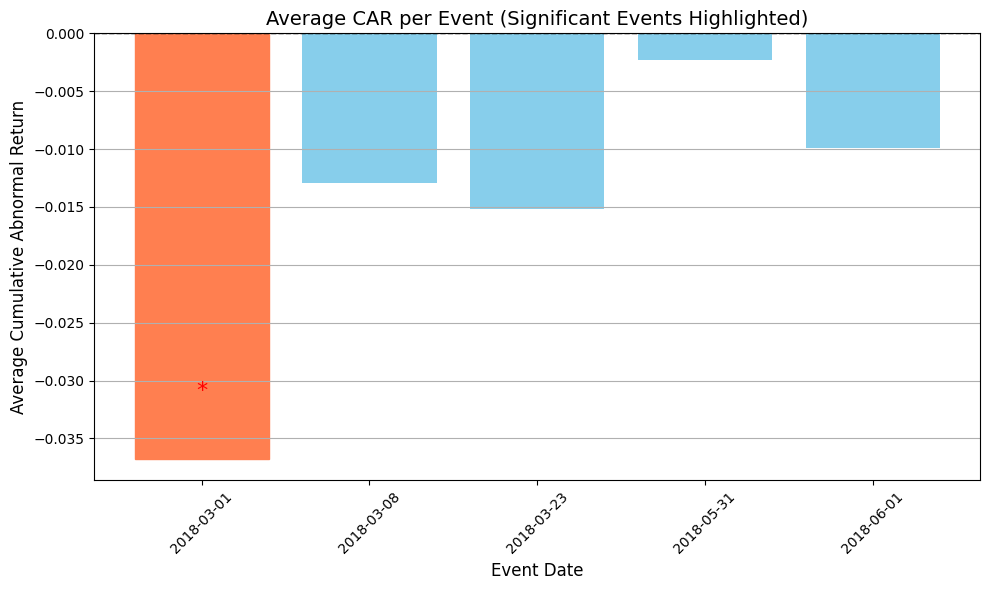

In [60]:
# Calculate average CAR across stocks for each event
average_CAR = CAR_df.mean(axis=1)

# Pull p-values from your t-test results
p_values = t_test_results_df['p-value']

# Create a bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(average_CAR.index.astype(str), average_CAR, color='skyblue')

# Highlight significant events
for i, event_date in enumerate(average_CAR.index):
    if p_values[event_date] < 0.05:
        bars[i].set_color('coral')  # Highlight significant bars in coral color
        plt.text(i, average_CAR[event_date] + 0.005, '*', ha='center', va='bottom', fontsize=16, color='red')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Average CAR per Event (Significant Events Highlighted)', fontsize=14)
plt.xlabel('Event Date', fontsize=12)
plt.ylabel('Average Cumulative Abnormal Return', fontsize=12)
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


"Among all tariff-related events analyzed, only the original announcement on March 1, 2018, produced a statistically significant abnormal return (p = 0.019). Other events showed no significant market reaction, consistent with the hypothesis that markets rapidly price in major policy changes upon initial announcement."

### Section 5: Beginning of Modeling !!

Now we are going to download more stocks so we can have a rich ml model to predict the future stock price .
estimate elasiticy changing price to tariffs

Panel regression

### Building Panel 2018

In [61]:
# Flatten stock returns
returns_long = log_returns.stack().reset_index()
returns_long.columns = ['Date', 'Ticker', 'Return']
# Prepare market returns
market_df = market_returns.reset_index()
market_df.columns = ['Date', 'MarketReturn']

# Merge
returns_long = returns_long.merge(market_df, on='Date', how='left')
# Sort first
returns_long = returns_long.sort_values(['Ticker', 'Date'])

# Calculate rolling 20-day volatility per stock
returns_long['Volatility'] = returns_long.groupby('Ticker')['Return'].rolling(window=20).std().reset_index(level=0, drop=True)
# 1. Clear the EventDummy
returns_long['EventDummy'] = 0

# 2. Keep only the significant event (March 1, 2018)
significant_event_date = pd.to_datetime("2018-03-01")

# 3. Define ±4 business day window
significant_event_window = pd.date_range(start=significant_event_date - pd.Timedelta(days=4),
                                         end=significant_event_date + pd.Timedelta(days=4),
                                         freq='B')  # 'B' = business day

# 4. Set EventDummy = 1 only for those dates
returns_long.loc[returns_long['Date'].isin(significant_event_window), 'EventDummy'] = 1

# Drop rows with missing Volatility
returns_long = returns_long.dropna(subset=['Volatility'])

returns_long.head()

,Date,Ticker,Return,MarketReturn,Volatility,EventDummy
152,2017-03-21,AA,-0.049335,-0.012486,0.033912,0
160,2017-03-22,AA,0.014049,0.001888,0.034179,0
168,2017-03-23,AA,-0.011343,-0.001061,0.031192,0
176,2017-03-24,AA,-0.022773,-0.000844,0.031508,0
184,2017-03-27,AA,-0.002768,-0.001020,0.031392,0


In [62]:
import statsmodels.formula.api as smf

# Run the OLS regression
model = smf.ols('Return ~ MarketReturn + Volatility + EventDummy', data=returns_long).fit(cov_type='HC1')  # HC1 = robust standard errors

# Print summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     89.03
Date:                Wed, 07 May 2025   Prob (F-statistic):           7.97e-55
Time:                        12:11:17   Log-Likelihood:                 6808.9
No. Observations:                2590   AIC:                        -1.361e+04
Df Residuals:                    2586   BIC:                        -1.359e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0004      0.001      0.360   

### Training Model Complete, Now starting with 2025 prediction

In [63]:
# Your stock tickers
tickers = ["SIM", 'HPS-A.TO', 'TSLA', 'CPB', 'GM', 'AA', 'F', 'CAT']
market_ticker = "^GSPC"

# Define download period: January 1 to March 1, 2025
start_date = "2024-10-01"
end_date = "2025-03-01"

# Download stock prices
price_data_2025 = yf.download(tickers, start=start_date, end=end_date)["Close"]

# Download market index prices
market_data_2025 = yf.download(market_ticker, start=start_date, end=end_date)["Close"]

# Save to CSV
price_data_2025.to_csv("price_data_2025.csv")
market_data_2025.to_csv("market_data_2025.csv")

print("Data successfully downloaded and saved to CSV.")


[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed

Data successfully downloaded and saved to CSV.


In [64]:
# Load the saved data
price_data_2025 = pd.read_csv("price_data_2025.csv", index_col=0, parse_dates=True)
market_data_2025 = pd.read_csv("market_data_2025.csv", index_col=0, parse_dates=True)
# Calculate daily log returns
log_returns_2025 = np.log(price_data_2025 / price_data_2025.shift(1))
market_returns_2025 = np.log(market_data_2025 / market_data_2025.shift(1))
# Flatten the stock returns into long format
returns_long_2025 = log_returns_2025.stack().reset_index()
returns_long_2025.columns = ['Date', 'Ticker', 'Return']

# Prepare market returns
market_2025_df = market_returns_2025.reset_index()
market_2025_df.columns = ['Date', 'MarketReturn']

# Merge stock returns with market returns
returns_long_2025 = returns_long_2025.merge(market_2025_df, on='Date', how='left')
# Sort correctly
returns_long_2025 = returns_long_2025.sort_values(['Ticker', 'Date'])

# Calculate 20-day rolling volatility per stock
returns_long_2025['Volatility'] = returns_long_2025.groupby('Ticker')['Return'].rolling(window=20).std().reset_index(level=0, drop=True)
# Initialize EventDummy
returns_long_2025['EventDummy'] = 0

# Define 4-day event window
event_date_2025 = pd.to_datetime('2025-02-10')
event_window_2025 = pd.date_range(start=event_date_2025, periods=4, freq='B')

# Set EventDummy = 1 for these dates
returns_long_2025.loc[returns_long_2025['Date'].isin(event_window_2025), 'EventDummy'] = 1
# Drop missing volatility values
returns_long_2025 = returns_long_2025.dropna(subset=['Volatility'])

returns_long_2025.head()

,Date,Ticker,Return,MarketReturn,Volatility,EventDummy
150,2024-10-29,AA,-0.008509,0.001613,0.023498,0
158,2024-10-30,AA,-0.009814,-0.003306,0.023650,0
166,2024-10-31,AA,-0.011655,-0.018790,0.022978,0
174,2024-11-01,AA,0.011902,0.004084,0.022509,0
182,2024-11-04,AA,0.003936,-0.002816,0.022455,0


In [69]:
# Predict 2025 returns
returns_long_2025['PredictedReturn'] = model.predict(returns_long_2025[['MarketReturn', 'Volatility', 'EventDummy']])

# Show results
returns_long_2025[['Date', 'Ticker', 'Return', 'PredictedReturn', 'MarketReturn', 'Volatility', 'EventDummy']].head()
returns_long_2025[returns_long_2025['EventDummy'] == 1]

# Access the p-values from the fitted model
p_values = model.pvalues

print("P-values for the model on the test set:")
print(p_values)


P-values for the model on the test set:
Intercept       7.187471e-01
MarketReturn    4.016270e-57
Volatility      7.724407e-01
EventDummy      2.421972e-02
dtype: float64


In [66]:
event_days_2025 = returns_long_2025[returns_long_2025['EventDummy'] == 1]
# Make a copy first
event_days_2025 = event_days_2025.copy()

# Then safely add the new column
event_days_2025['Error'] = event_days_2025['Return'] - event_days_2025['PredictedReturn']
# Mean Prediction Error
mean_error = event_days_2025['Error'].mean()
print(f"Mean Prediction Error: {mean_error:.6f}")
# RMSE
rmse = np.sqrt((event_days_2025['Error'] ** 2).mean())
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
# MAE
mae = event_days_2025['Error'].abs().mean()
print(f"Mean Absolute Error (MAE): {mae:.6f}")
event_days_2025[['Date', 'Ticker', 'Return', 'PredictedReturn', 'Error']].head()




Mean Prediction Error: -0.000862
Root Mean Squared Error (RMSE): 0.023969
Mean Absolute Error (MAE): 0.016559


,Date,Ticker,Return,PredictedReturn,Error
682,2025-02-10,AA,0.021907,0.001199,0.020707
690,2025-02-11,AA,0.006749,-0.004368,0.011117
698,2025-02-12,AA,-0.022858,-0.007066,-0.015792
706,2025-02-13,AA,0.001375,0.004424,-0.003049
683,2025-02-10,CAT,-0.001815,0.001364,-0.003180


In [67]:
from sklearn.metrics import r2_score

# R-squared
r2 = r2_score(event_days_2025['Return'], event_days_2025['PredictedReturn'])
print(f"R-squared: {r2:.6f}")


R-squared: 0.052190


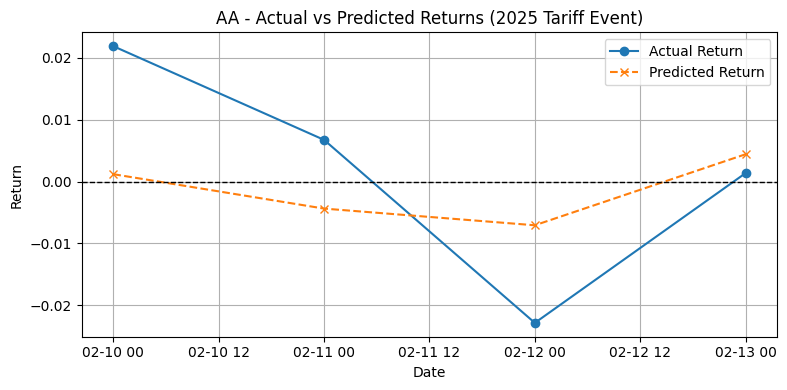

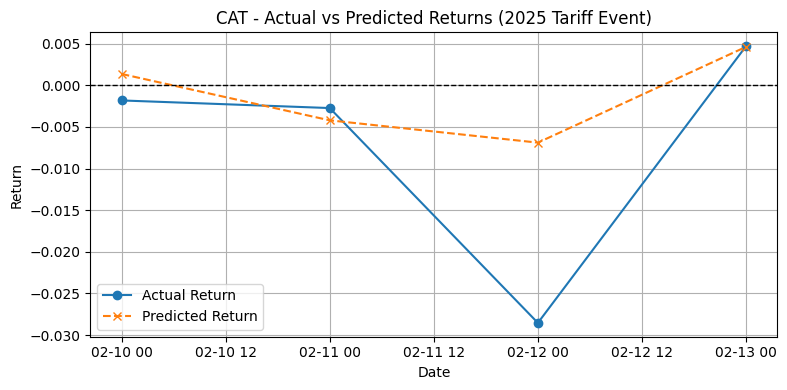

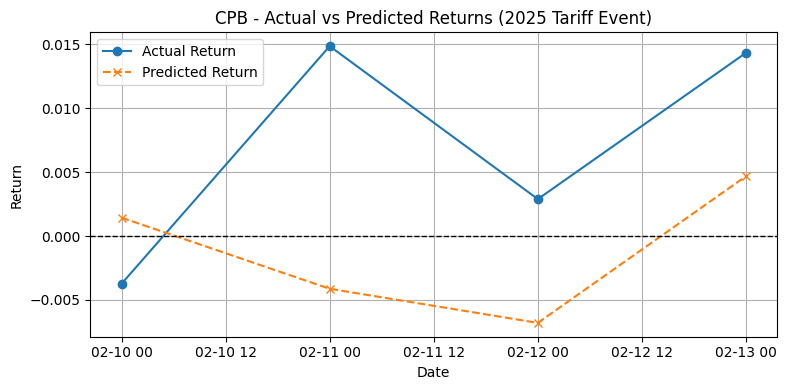

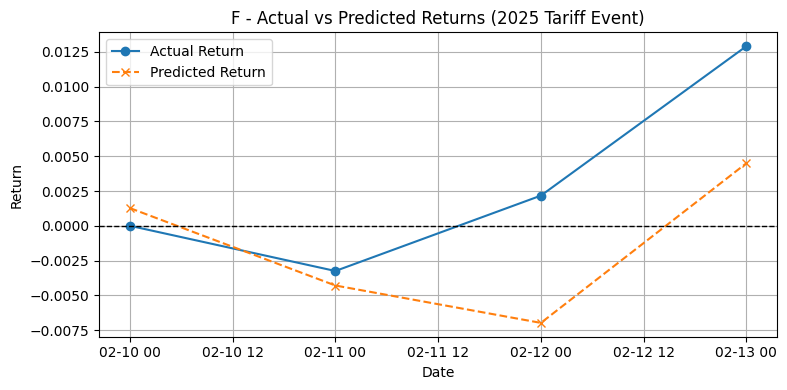

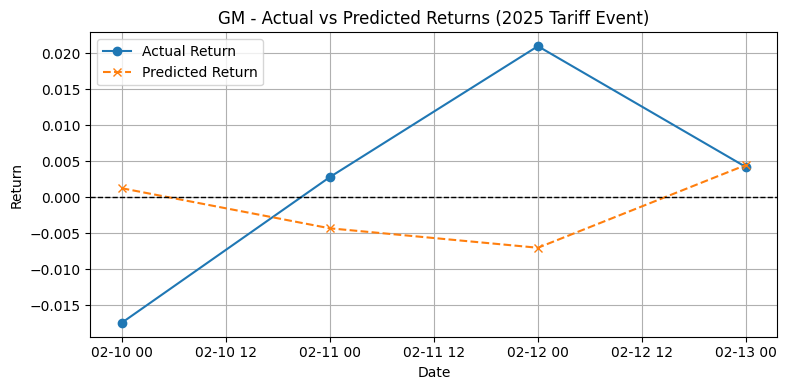

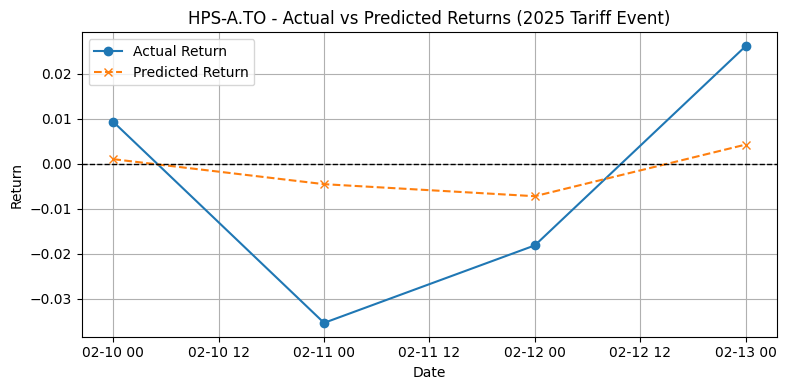

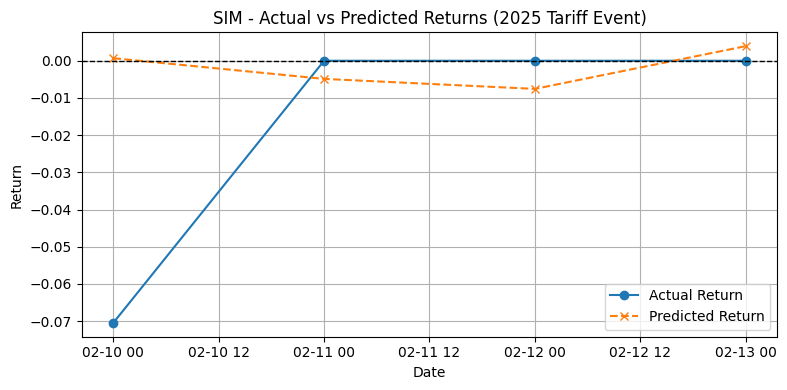

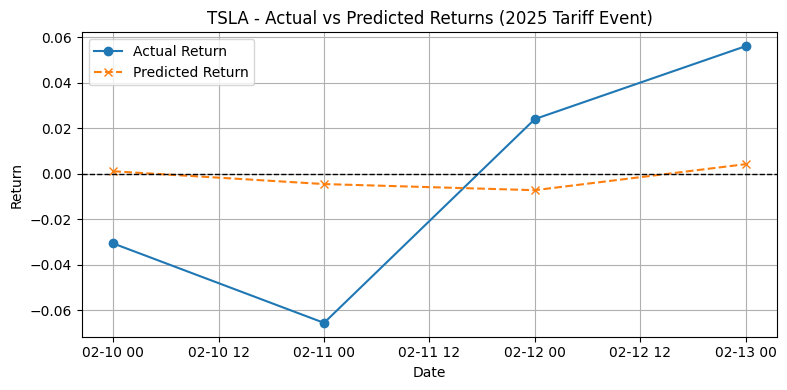

In [68]:
# Get list of unique stocks
unique_stocks = event_days_2025['Ticker'].unique()

# Loop through each stock
for ticker in unique_stocks:
    # Filter data for the current stock
    stock_data = event_days_2025[event_days_2025['Ticker'] == ticker]
    
    plt.figure(figsize=(8, 4))
    
    # Actual Return
    plt.plot(stock_data['Date'], stock_data['Return'], marker='o', label='Actual Return', linestyle='-')
    
    # Predicted Return
    plt.plot(stock_data['Date'], stock_data['PredictedReturn'], marker='x', label='Predicted Return', linestyle='--')
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f'{ticker} - Actual vs Predicted Returns (2025 Tariff Event)')
    plt.xlabel('Date')
    plt.ylabel('Return')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
